<a href="https://colab.research.google.com/github/rishitharee24-create/maths/blob/main/Unit5q6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Circuit natural frequency = 3.00 rad/s
n= 1  omega_n=  1.0  |Vn|= 12.732  |Z|= 8.0025  |I_n|=  1.5911
n= 3  omega_n=  3.0  |Vn|=  4.244  |Z|= 0.2000  |I_n|= 21.2207
n= 5  omega_n=  5.0  |Vn|=  2.546  |Z|= 3.2062  |I_n|=  0.7942
n= 7  omega_n=  7.0  |Vn|=  1.819  |Z|= 5.7178  |I_n|=  0.3181
n= 9  omega_n=  9.0  |Vn|=  1.415  |Z|= 8.0025  |I_n|=  0.1768
n=11  omega_n= 11.0  |Vn|=  1.157  |Z|=10.1838  |I_n|=  0.1137

Resonance occurs at harmonic n = 3 (omega = 3.0 rad/s = natural frequency 3.00 rad/s)


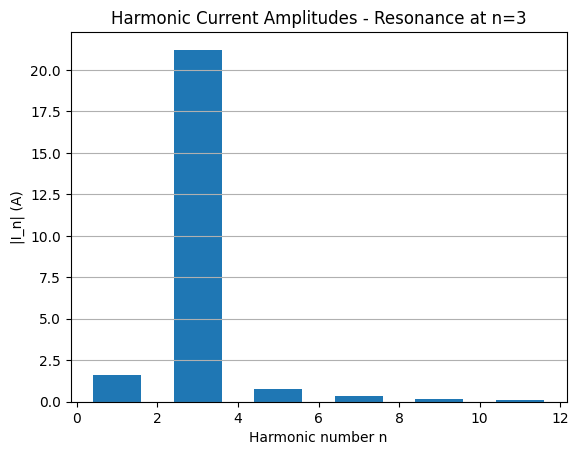

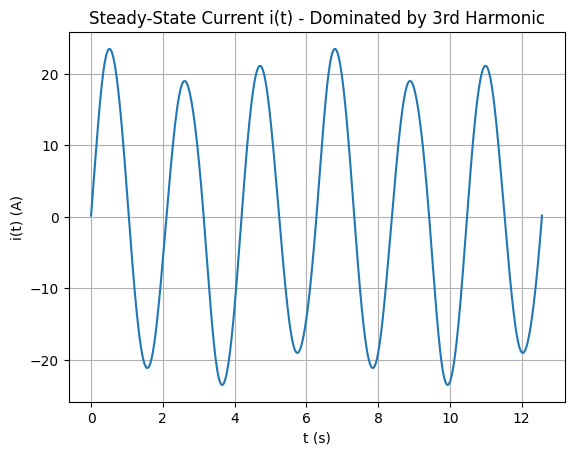

In [30]:
import numpy as np
import matplotlib.pyplot as plt

V0, R, L, C = 10, 0.2, 1, 1/9.0
omega0 = 1.0  # fundamental angular frequency
omega_nat = 1/np.sqrt(L*C)
print(f"Circuit natural frequency = {omega_nat:.2f} rad/s")

harmonics = list(range(1, 12, 2))  # odd harmonics: 1,3,5,7,...
results = []
for n in harmonics:
    Vn = 4*V0/(n*np.pi)            # Fourier coefficient of harmonic n
    omega_n = n*omega0
    Z = np.sqrt(R**2 + (omega_n*L - 1/(omega_n*C))**2)  # impedance magnitude
    In = Vn/Z                        # steady-state current amplitude
    results.append((n, omega_n, Vn, Z, In))
    print(f"n={n:2d}  omega_n={omega_n:5.1f}  |Vn|={Vn:7.3f}  |Z|={Z:7.4f}  |I_n|={In:8.4f}")

# Identify resonant harmonic
n_res = min(results, key=lambda r: r[3])[0]
print(f"\nResonance occurs at harmonic n = {n_res} "
      f"(omega = {n_res*omega0} rad/s = natural frequency {omega_nat:.2f} rad/s)")

# Plot harmonic current amplitudes
ns = [r[0] for r in results]
Is = [r[4] for r in results]
plt.bar(ns, Is, width=1.2)
plt.xlabel('Harmonic number n'); plt.ylabel('|I_n| (A)')
plt.title('Harmonic Current Amplitudes - Resonance at n=3')
plt.grid(True, axis='y')
plt.savefig('p26_forced_oscillation_resonance.png', dpi=120)
plt.show()

# Reconstruct total steady-state current waveform
t = np.linspace(0, 4*np.pi, 1000)
i_total = np.zeros_like(t)
for n, omega_n, Vn, Z, In in results:
    phase = -np.arctan2(omega_n*L - 1/(omega_n*C), R)
    i_total += In*np.sin(omega_n*t + phase)

plt.figure()
plt.plot(t, i_total)
plt.title('Steady-State Current i(t) - Dominated by 3rd Harmonic')
plt.xlabel('t (s)'); plt.ylabel('i(t) (A)'); plt.grid(True)
plt.savefig('p26_current_waveform.png', dpi=120)
plt.show()











